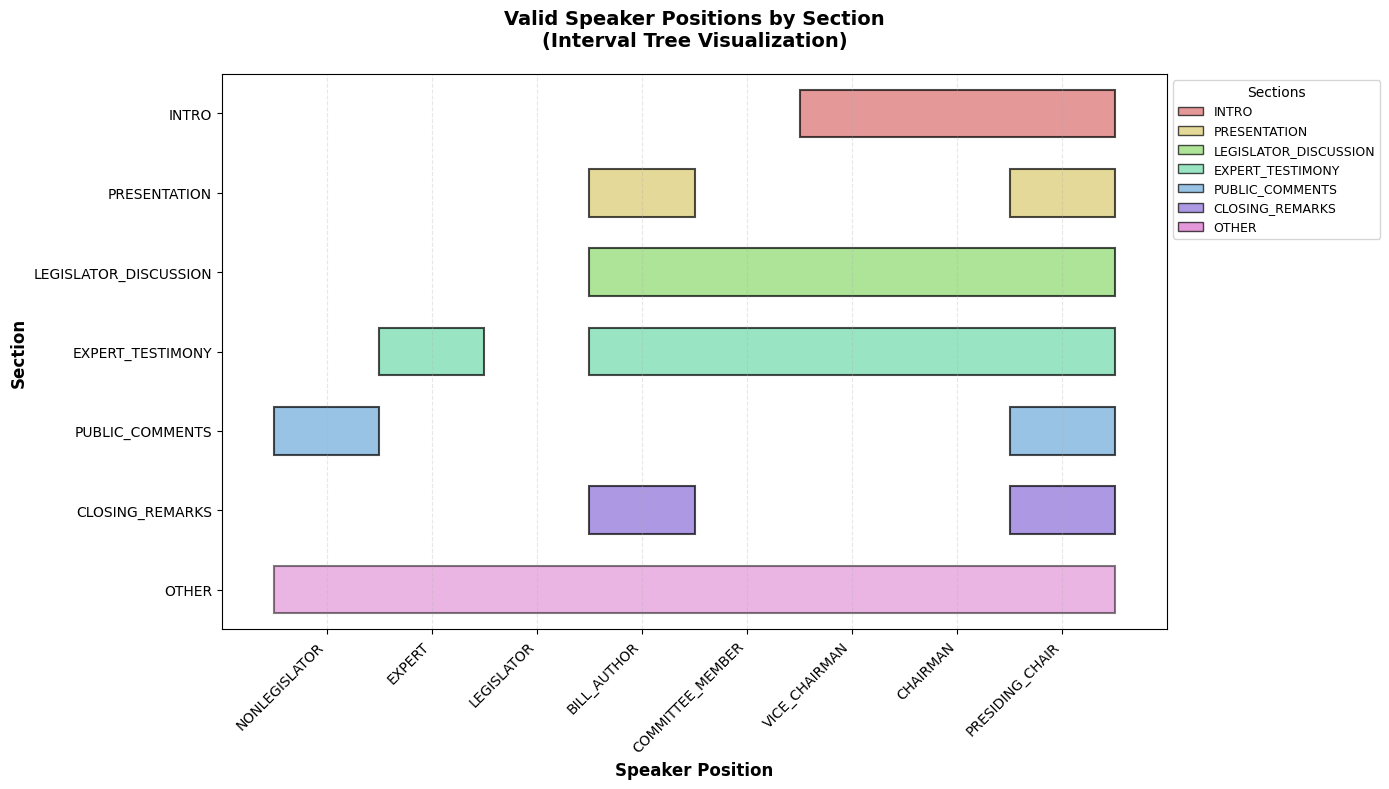

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import PatchCollection
from src.speakers.enums.SpeakerPositionEnum import SpeakerPositionEnum
from src.speakers.validation.SectionRoleRequirementsEnum import SectionSpeakerRequirementsEnum

# Generate mellow HSV colors for each section
num_sections = len(SectionSpeakerRequirementsEnum)
section_colors = {}
for i, section_enum in enumerate(SectionSpeakerRequirementsEnum):
    hue = i / num_sections
    # Use mellow saturation and value for softer colors
    rgb = mcolors.hsv_to_rgb([hue, 0.5, 0.85])
    section_colors[section_enum.name] = rgb

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Y-axis positions for each section
y_positions = {section: 6-i for i, section in enumerate(SectionSpeakerRequirementsEnum)}
section_names = [s.name for s in SectionSpeakerRequirementsEnum]

# Get speaker position range (min to max value)
speaker_positions = {sp: sp.value for sp in SpeakerPositionEnum}
min_pos = min(speaker_positions.values())
max_pos = max(speaker_positions.values())

# Plot intervals for each section
for section_enum in SectionSpeakerRequirementsEnum:
    y_pos = y_positions[section_enum]
    section_name = section_enum.name
    requirements = section_enum.value
    
    # Skip if no intervals (OTHER section)
    if requirements.valid_speaker_position_intervals is None:
        # Draw a full-width grayed interval for OTHER
        rect = mpatches.Rectangle(
            (min_pos - 0.5, y_pos - 0.3),
            max_pos - min_pos + 1,
            0.6,
            facecolor=section_colors.get(section_name, '#D3D3D3'),
            edgecolor='black',
            alpha=0.5,
            linewidth=1.5
        )
        ax.add_patch(rect)
        continue
    
    # Draw each interval
    for interval_start, interval_end in requirements.valid_speaker_position_intervals:
        width = interval_end - interval_start + 1
        rect = mpatches.Rectangle(
            (interval_start - 0.5, y_pos - 0.3),
            width,
            0.6,
            facecolor=section_colors.get(section_name, '#D3D3D3'),
            edgecolor='black',
            alpha=0.7,
            linewidth=1.5
        )
        ax.add_patch(rect)

# Configure axes
ax.set_xlim(min_pos - 1, max_pos + 1)
ax.set_ylim(-0.5, len(section_names) - 0.5)

# X-axis: Speaker positions
ax.set_xticks(list(speaker_positions.values()))
ax.set_xticklabels([sp.name for sp in SpeakerPositionEnum], rotation=45, ha='right')
ax.set_xlabel('Speaker Position', fontsize=12, fontweight='bold')

# Y-axis: Sections
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(section_names, fontsize=10)
ax.set_ylabel('Section', fontsize=12, fontweight='bold')

# Title
ax.set_title('Valid Speaker Positions by Section\n(Interval Tree Visualization)', 
             fontsize=14, fontweight='bold', pad=20)

# Grid
ax.grid(True, axis='x', alpha=0.3, linestyle='--')

# Legend (outside the plot)
legend_elements = [
    mpatches.Patch(facecolor=color, edgecolor='black', label=section, alpha=0.7)
    for section, color in section_colors.items()
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper left',
          title='Sections', fontsize=9, frameon=True)

plt.tight_layout()
plt.show()